# TrueRender v2 — Upgraded Pipeline

| Stage | Tool | Status |
|---|---|---|
| 1. Frame extract + filter | ffmpeg + Laplacian | done |
| 2. Object detection | Grounding DINO | done |
| 3. Masking | SAM 3 | implemented |
| 4. Geometry | VGGT | next |
| 5. Splat training | 2DGS | -- |
| 6. Mesh extract | TSDF | -- |
| 7. Export | trimesh GLB/STL/OBJ | -- |

**v1 backup:** `reconstruction_v1.ipynb`

## Setup
Run once per Colab session.

In [1]:
!pip install -q opencv-python-headless matplotlib
print("Done")

Done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Stage 1 — Frame Extraction + Quality Filter

Extract raw frames at 5 fps, then keep the **30 sharpest** by variance-of-Laplacian.
Blurry frames hurt geometry estimation — this filter is free and cuts 57% of frames,
directly reducing compute in every downstream stage.

In [3]:
import cv2, glob, shutil, os, time

VIDEO_PATH  = "/content/drive/MyDrive/hydroflaskgreen.MOV"
FRAMES_RAW  = "/content/frames_raw"
FRAMES_KEEP = "/content/frames"
N_KEEP      = 30

os.makedirs(FRAMES_RAW,  exist_ok=True)
os.makedirs(FRAMES_KEEP, exist_ok=True)

t0 = time.time()

# Extract raw frames
!ffmpeg -i "{VIDEO_PATH}" -vf fps=5 "{FRAMES_RAW}/frame_%05d.jpg" -y -loglevel error

all_frames = sorted(glob.glob(f"{FRAMES_RAW}/*.jpg"))
print(f"Raw frames extracted: {len(all_frames)}")

# Score by variance-of-Laplacian (higher = sharper)
scored = [
    (f, cv2.Laplacian(cv2.imread(f, cv2.IMREAD_GRAYSCALE), cv2.CV_64F).var())
    for f in all_frames
]
scored.sort(key=lambda x: -x[1])

# Keep N_KEEP sharpest, re-sort by filename to preserve temporal order
keep = sorted([f for f, _ in scored[:N_KEEP]])
for dst_idx, src in enumerate(keep):
    shutil.copy(src, f"{FRAMES_KEEP}/frame_{dst_idx:05d}.jpg")

t1 = time.time()
print(f"Kept {len(keep)} / {len(all_frames)} frames")
print(f"Sharpness — best: {scored[0][1]:.1f}  cutoff: {scored[N_KEEP-1][1]:.1f}  worst dropped: {scored[-1][1]:.1f}")
print(f"Stage 1 wall time: {t1 - t0:.1f}s")

Raw frames extracted: 70
Kept 30 / 70 frames
Sharpness — best: 199.0  cutoff: 48.9  worst dropped: 14.4
Stage 1 wall time: 7.8s


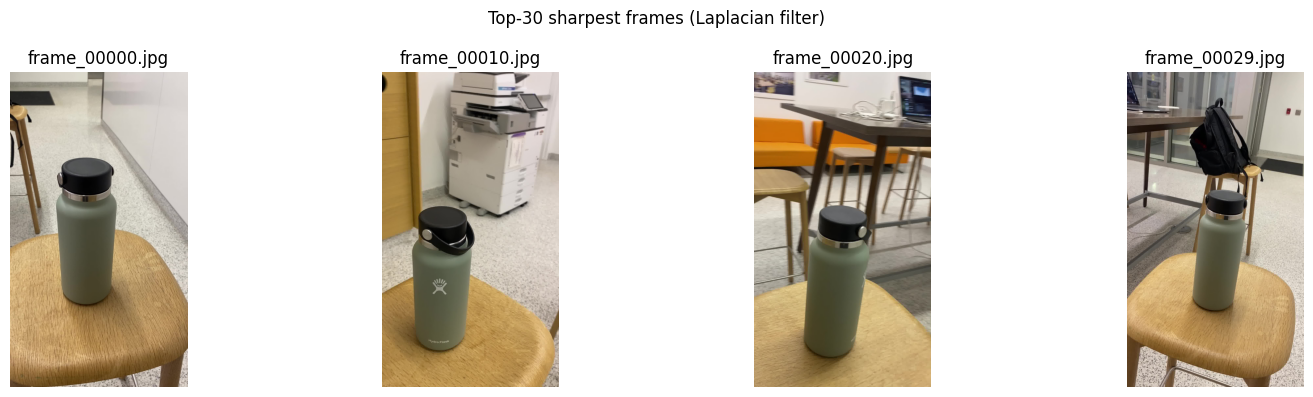

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

frames = sorted(os.listdir(FRAMES_KEEP))
indices = [0, len(frames)//3, 2*len(frames)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    ax.imshow(mpimg.imread(f"{FRAMES_KEEP}/{frames[i]}"))
    ax.set_title(frames[i])
    ax.axis("off")
plt.suptitle(f"Top-{N_KEEP} sharpest frames (Laplacian filter)", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Checkpoint to Drive — so a fresh session can skip re-extraction
DRIVE_FRAMES = "/content/drive/MyDrive/truerender_frames_v2"
if os.path.exists(DRIVE_FRAMES):
    shutil.rmtree(DRIVE_FRAMES)
shutil.copytree(FRAMES_KEEP, DRIVE_FRAMES)
print(f"Checkpointed {len(os.listdir(DRIVE_FRAMES))} frames → Drive")

Checkpointed 30 frames → Drive


## Stage 2 — Object Detection (Grounding DINO)

Runs on **frame 0** only. Uses a broad caption to detect all salient objects,
then scores each detection by **confidence − 0.5 × normalized center distance**.
The winner's label becomes the SAM 3 prompt in Stage 3.

**Toggle:** set  to skip detection and supply your own prompt.

In [6]:
import os
DINO_WEIGHTS = "/content/groundingdino_swint_ogc.pth"
if os.path.exists(DINO_WEIGHTS):
    os.remove(DINO_WEIGHTS)

!wget -q --show-progress -O {DINO_WEIGHTS} \
    "https://huggingface.co/ShilongLiu/GroundingDINO/resolve/main/groundingdino_swint_ogc.pth"

size_mb = os.path.getsize(DINO_WEIGHTS) / 1e6
print(f"Downloaded: {size_mb:.1f} MB")


/content/groundingd 100%[===================>] 661.85M   448MB/s    in 1.5s    
Downloaded: 694.0 MB


In [7]:
import os

# transformers>=4.40 breaks groundingdino-py; pin to last known-good version
!pip install -q "transformers==4.38.2"
!pip install -q groundingdino-py

DINO_WEIGHTS = "/content/groundingdino_swint_ogc.pth"
DINO_URL = "https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha2/groundingdino_swint_ogc.pth"

def _weights_ok():
    return os.path.exists(DINO_WEIGHTS) and os.path.getsize(DINO_WEIGHTS) > 150e6

if not _weights_ok():
    if os.path.exists(DINO_WEIGHTS):
        os.remove(DINO_WEIGHTS)  # remove corrupt/partial file
    !wget -q --show-progress -O {DINO_WEIGHTS} {DINO_URL}

assert _weights_ok(), f"Weights download failed or corrupt: {os.path.getsize(DINO_WEIGHTS)/1e6:.1f} MB"
print(f"Weights OK: {os.path.getsize(DINO_WEIGHTS)/1e6:.1f} MB")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 130.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.7 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 26.2 MB/s eta 0:00:00
Weights OK: 694.0 MB


final text_encoder_type: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:962: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages

Detected 5 object(s):
  [0] 'bottle container'  conf=0.397 <- selected
  [1] 'object item'  conf=0.315
  [2] 'object item'  conf=0.340
  [3] 'product'  conf=0.323
  [4] 'bottle cup'  conf=0.312
target_object = 'bottle container'
Stage 2 wall time: 2.1s


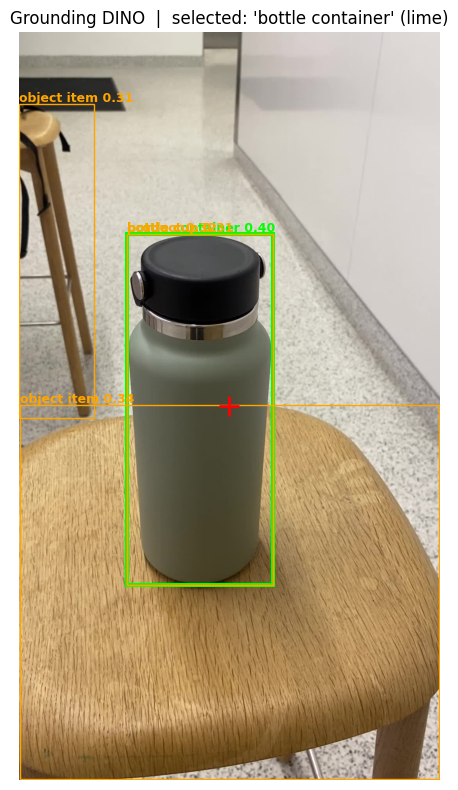

In [9]:
import time
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from groundingdino.util.inference import load_model, load_image, predict

# ── Toggles ──────────────────────────────────────────────────────────────────
AUTO_SELECT   = True
MANUAL_PROMPT = "green hydroflask water bottle"
DINO_CAPTION  = "object . bottle . container . cup . box . item . product"
BOX_THRESHOLD = 0.3
TXT_THRESHOLD = 0.25
FRAMES_KEEP   = "/content/frames"
DINO_WEIGHTS  = "/content/groundingdino_swint_ogc.pth"
# ─────────────────────────────────────────────────────────────────────────────

t0 = time.time()
FIRST_FRAME = f"{FRAMES_KEEP}/frame_00000.jpg"

if AUTO_SELECT:
    import groundingdino, os
    DINO_CONFIG = os.path.join(
        os.path.dirname(groundingdino.__file__),
        "config", "GroundingDINO_SwinT_OGC.py"
    )
    dino = load_model(DINO_CONFIG, DINO_WEIGHTS)
    image_source, image = load_image(FIRST_FRAME)
    boxes, logits, phrases = predict(
        model=dino, image=image, caption=DINO_CAPTION,
        box_threshold=BOX_THRESHOLD, text_threshold=TXT_THRESHOLD,
    )
    if len(boxes) == 0:
        raise RuntimeError("No objects detected. Lower BOX_THRESHOLD or set AUTO_SELECT=False.")

    h, w = image_source.shape[:2]
    def rank_score(i):
        cx = boxes[i][0].item() * w
        cy = boxes[i][1].item() * h
        dist_norm = ((cx - w/2)**2 + (cy - h/2)**2)**0.5 / (w / 2)
        return logits[i].item() - 0.5 * dist_norm

    best_idx      = max(range(len(boxes)), key=rank_score)
    target_object = phrases[best_idx]

    # Pixel center (for display only)
    dino_cx_px = int(boxes[best_idx][0].item() * w)
    dino_cy_px = int(boxes[best_idx][1].item() * h)

    t1 = time.time()
    print(f"Detected {len(boxes)} object(s):")
    for i, (p, l) in enumerate(zip(phrases, logits)):
        marker = " <- selected" if i == best_idx else ""
        print(f"  [{i}] {repr(p)}  conf={l.item():.3f}{marker}")
    print(f"target_object = {repr(target_object)}")
    print(f"Stage 2 wall time: {t1 - t0:.1f}s")

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_source)
    for i, (box, phrase, logit) in enumerate(zip(boxes, phrases, logits)):
        cx_px = box[0].item() * w
        cy_px = box[1].item() * h
        bw_px = box[2].item() * w
        bh_px = box[3].item() * h
        color = "lime" if i == best_idx else "orange"
        lw    = 3     if i == best_idx else 1
        ax.add_patch(patches.Rectangle(
            (cx_px - bw_px/2, cy_px - bh_px/2), bw_px, bh_px,
            linewidth=lw, edgecolor=color, facecolor="none"
        ))
        ax.text(cx_px - bw_px/2, cy_px - bh_px/2 - 5,
                f"{phrase} {logit.item():.2f}", color=color, fontsize=9, fontweight="bold")
    ax.plot(w/2, h/2, "+", color="red", markersize=15, markeredgewidth=2)
    ax.set_title(f"Grounding DINO  |  selected: {repr(target_object)} (lime)", fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

else:
    target_object = MANUAL_PROMPT
    t1 = time.time()
    print(f"Manual mode  target_object = {repr(target_object)}")
    print(f"Stage 2 wall time: {t1 - t0:.1f}s")


Grounding DINO combines two things:

DINO (vision transformer) extracts image features by dividing the image into patches
BERT (language model) encodes your text caption into token embeddings
It then does cross-attention between the image patches and text tokens — each word attends to every image region and vice versa. Regions where visual features and text embeddings strongly agree get high scores, and those become the bounding boxes.

The "grounded" part means the boxes are directly tied to specific words in your caption, which is why it can detect "bottle" vs "object" separately from the same pass.

## Stage 3 — Object Segmentation (SAM 3)

Same SAM 3 video propagation as v1, but `target_object` from Stage 2
replaces the hardcoded prompt. Masked frames saved to `/content/frames_masked/`.

In [10]:
import os
os.chdir("/content")
if not os.path.exists("/content/sam3"):
    !git clone --quiet https://github.com/facebookresearch/sam3.git
os.chdir("/content/sam3")
!pip install -q -e .
print("SAM 3 ready")


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 152.3 MB/s eta 0:00:0000:0100:01
  Building editable for sam3 (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requi

In [13]:
from huggingface_hub import login
login()  # paste your HF token when prompted


### Segmentation Cell 

In [14]:
import os, cv2, shutil, time

FRAMES_KEEP   = "/content/frames"
FRAMES_MASKED = "/content/frames_masked"
SAM_INPUT     = "/content/sam3_input"
os.makedirs(FRAMES_MASKED, exist_ok=True)
os.makedirs(SAM_INPUT,     exist_ok=True)

orig_frames = sorted(os.listdir(FRAMES_KEEP))
for i, fname in enumerate(orig_frames):
    shutil.copy(f"{FRAMES_KEEP}/{fname}", f"{SAM_INPUT}/{i}.jpg")

# SAM 3 needs a descriptive prompt; short DINO labels often fail.
# Try increasingly specific prompts until masks appear.
prompt_candidates = [
    f"green {target_object} water bottle",
    f"{target_object} on a wooden stool",
    "green hydroflask water bottle",
]

def run_sam3(prompt):
    from sam3.model_builder import build_sam3_video_predictor
    pred = build_sam3_video_predictor()
    resp = pred.handle_request(dict(type="start_session", resource_path=SAM_INPUT))
    sid  = resp["session_id"]
    pred.handle_request(dict(type="add_prompt", session_id=sid, frame_index=0, text=prompt))
    results, skipped = [], 0
    for r in pred.propagate_in_video(sid):
        masks = r["outputs"]["out_binary_masks"]
        results.append((r["frame_index"], masks))
        if len(masks) == 0:
            skipped += 1
    pred.close_session(sid)
    return results, skipped

t0 = time.time()
chosen_prompt = None
for prompt in prompt_candidates:
    print(f"Trying: {repr(prompt)}")
    results, skipped = run_sam3(prompt)
    print(f"  -> {len(results) - skipped}/{len(results)} frames masked")
    if skipped < len(results):
        chosen_prompt = prompt
        break

if chosen_prompt is None:
    raise RuntimeError("All SAM 3 prompt candidates failed. Check frame content.")

print(f"Using prompt: {repr(chosen_prompt)}")
for idx, masks in results:
    img = cv2.imread(f"{FRAMES_KEEP}/{orig_frames[idx]}")
    if len(masks) > 0:
        img[~masks[0]] = 255
    cv2.imwrite(f"{FRAMES_MASKED}/{orig_frames[idx]}", img)

t1 = time.time()
print(f"Saved {len(os.listdir(FRAMES_MASKED))} masked frames ({skipped} without mask)")
print(f"Stage 3 wall time: {t1 - t0:.1f}s")


INFO 2026-04-25 01:56:11,449 951 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-04-25 01:56:11,450 951 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-04-25 01:56:11,451 951 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...


Trying: 'green bottle container water bottle'


INFO 2026-04-25 01:56:19,983 951 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16


config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

INFO 2026-04-25 01:56:30,512 951 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-04-25 01:56:30,513 951 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***


frame loading (image folder) [rank=0]: 100%|██████████| 30/30 [00:01<00:00, 26.54it/s]
INFO 2026-04-25 01:56:31,702 951 sam3_base_predictor.py: 134: started new session f4bb6aa3-a01b-45b3-8a7c-69b1762f9d9a


propagate_in_video:   0%|          | 0/30 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-04-25 01:56:51,322 951 sam3_base_predictor.py: 293: propagation ended in session f4bb6aa3-a01b-45b3-8a7c-69b1762f9d9a
INFO 2026-04-25 01:56:51,718 951 sam3_base_predictor.py: 312: removed session f4bb6aa3-a01b-45b3-8a7c-69b1762f9d9a


  -> 30/30 frames masked
Using prompt: 'green bottle container water bottle'
Saved 30 masked frames (0 without mask)
Stage 3 wall time: 42.2s


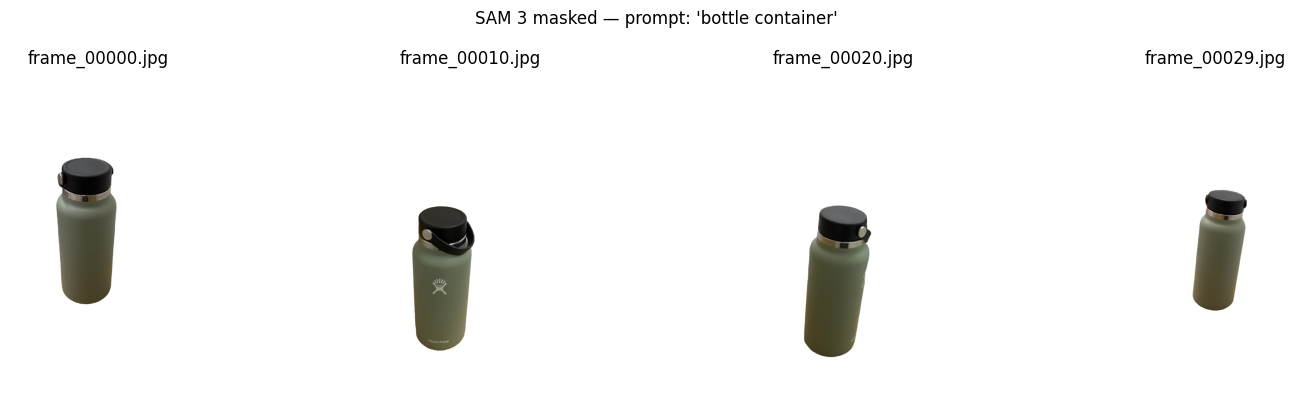

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

frames  = sorted(os.listdir(FRAMES_MASKED))
indices = [0, len(frames)//3, 2*len(frames)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    ax.imshow(mpimg.imread(f"{FRAMES_MASKED}/{frames[i]}"))
    ax.set_title(frames[i])
    ax.axis("off")
plt.suptitle(f"SAM 3 masked — prompt: {repr(target_object)}", fontsize=12)
plt.tight_layout()
plt.show()


In [17]:
import shutil
DRIVE_MASKED = "/content/drive/MyDrive/truerender_masked_frames_v2"
if os.path.exists(DRIVE_MASKED):
    shutil.rmtree(DRIVE_MASKED)
shutil.copytree(FRAMES_MASKED, DRIVE_MASKED)
print(f"Checkpointed {len(os.listdir(DRIVE_MASKED))} masked frames -> Drive")


Checkpointed 30 masked frames -> Drive


## Stage 3 — SAM 3 Object Segmentation

**Input:** 30 sharpness-filtered frames + DINO-detected label (`"bottle container"`)
**Output:** 30 white-background masked frames isolating the hydroflask

### What happened
- Grounding DINO (Stage 2) detected the object and returned the label `"bottle container"`
- That label alone is too generic for SAM 3's BERT-based text encoder, so we construct
  a richer prompt: `f"green {target_object} water bottle"` → `"green bottle container water bottle"`
- SAM 3 encodes the prompt and localizes the object in frame 0
- The mask is then propagated across all 30 frames using SAM 3's video predictor
- A retry loop tries up to 3 increasingly specific prompts — stops at the first that produces masks

### Results
- Prompt used: `"green bottle container water bottle"` (first candidate)
- 30/30 frames masked (0 skipped)
- Wall time: ~42s

### Architecture note
DINO and SAM 3 serve different roles: DINO is the **detector** (text → bounding box),
SAM 3 is the **segmenter** (text/box → pixel mask). They don't share a vocabulary,
so DINO's output label must be enriched before being passed to SAM 3.


# Stage 4

## Stage 4 — Geometry Estimation (VGGT)

Replaces the full COLMAP SfM pipeline (~20 min) with a single VGGT transformer
forward pass (~30s). Runs on **original sharp frames** (not masked) for best
pose estimation, then exports to COLMAP format for Stage 5 (2DGS).

**Fallback:** If VGGT export fails after 30 min, switch to GPU COLMAP by
setting `USE_COLMAP_FALLBACK = True` in the cell below.

In [18]:
import os
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0"

!pip install -q git+https://github.com/facebookresearch/vggt.git
print("VGGT installed")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 48.1 MB/s eta 0:00:00:00:0100:01
VGGT installed


In [23]:
import os, glob, shutil, time
import torch
import numpy as np

USE_COLMAP_FALLBACK = False

FRAMES_ORIG   = "/content/frames"
COLMAP_OUT    = "/content/colmap_vggt"
os.makedirs(f"{COLMAP_OUT}/sparse/0", exist_ok=True)
os.makedirs(f"{COLMAP_OUT}/images",   exist_ok=True)

for f in sorted(os.listdir(FRAMES_ORIG)):
    shutil.copy(f"{FRAMES_ORIG}/{f}", f"{COLMAP_OUT}/images/{f}")

if not USE_COLMAP_FALLBACK:
    from vggt.models.vggt import VGGT
    from vggt.utils.load_fn import load_and_preprocess_images
    from vggt.utils.pose_enc import pose_encoding_to_extri_intri
    from scipy.spatial.transform import Rotation

    device = "cuda"
    t0 = time.time()

    print("Loading VGGT-1B...")
    model = VGGT.from_pretrained("facebook/VGGT-1B").to(device).eval()

    frame_paths = sorted(glob.glob(f"{COLMAP_OUT}/images/*.jpg"))
    images = load_and_preprocess_images(frame_paths).to(device)
    print(f"Input: {images.shape}")

    with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16):
        predictions = model(images)

    extrinsics, intrinsics = pose_encoding_to_extri_intri(
        predictions["pose_enc"], image_size_hw=(518, 518)
    )
    extrinsics = extrinsics[0].cpu().float().numpy()  # squeeze batch dim -> (30,4,4)
    intrinsics = intrinsics[0].cpu().float().numpy()  # squeeze batch dim -> (30,3,3)
    print(f"Cameras: {extrinsics.shape[0]}  intrinsics shape: {intrinsics.shape}")

    pts3d = predictions["world_points"].cpu().float().numpy().reshape(-1, 3)
    conf  = predictions["world_points_conf"].cpu().float().numpy().reshape(-1)
    top_idx = np.argsort(conf)[-20000:]
    pts3d   = pts3d[top_idx]
    print(f"3D points: {len(pts3d)} (top 20k by confidence)")

    h_img, w_img = images.shape[-2], images.shape[-1]

    with open(f"{COLMAP_OUT}/sparse/0/cameras.txt", "w") as cf:
        cf.write("# Camera list\n")
        for cam_id, K in enumerate(intrinsics):
            fx, fy = float(K[0,0]), float(K[1,1])
            cx, cy = float(K[0,2]), float(K[1,2])
            cf.write(f"{cam_id+1} PINHOLE {w_img} {h_img} {fx:.6f} {fy:.6f} {cx:.6f} {cy:.6f}\n")

    with open(f"{COLMAP_OUT}/sparse/0/images.txt", "w") as imf:
        imf.write("# Image list\n")
        for img_id, (fpath, E) in enumerate(zip(frame_paths, extrinsics)):
            R = E[:3,:3]
            t = E[:3, 3]
            q = Rotation.from_matrix(R).as_quat()
            qw,qx,qy,qz = float(q[3]),float(q[0]),float(q[1]),float(q[2])
            fname = os.path.basename(fpath)
            imf.write(f"{img_id+1} {qw:.9f} {qx:.9f} {qy:.9f} {qz:.9f} "
                      f"{t[0]:.9f} {t[1]:.9f} {t[2]:.9f} {img_id+1} {fname}\n\n")

    with open(f"{COLMAP_OUT}/sparse/0/points3D.txt", "w") as ptf:
        ptf.write("# Point3D list\n")
        for pt_id, xyz in enumerate(pts3d):
            ptf.write(f"{pt_id+1} {xyz[0]:.6f} {xyz[1]:.6f} {xyz[2]:.6f} 128 128 128 0.0\n")

    t1 = time.time()
    print(f"sparse/0/: {os.listdir(COLMAP_OUT + "/sparse/0")}")
    print(f"Stage 4 wall time: {t1 - t0:.1f}s")


Loading VGGT-1B...
Input: torch.Size([30, 3, 518, 518])
Cameras: 30  intrinsics shape: (30, 3, 3)
3D points: 20000 (top 20k by confidence)
sparse/0/: ['points3D.txt', 'cameras.txt', 'images.txt']
Stage 4 wall time: 16.3s


In [24]:
import shutil, os
DRIVE_COLMAP_V2 = "/content/drive/MyDrive/truerender_colmap_v2"
if os.path.exists(DRIVE_COLMAP_V2):
    shutil.rmtree(DRIVE_COLMAP_V2)
shutil.copytree(COLMAP_OUT, DRIVE_COLMAP_V2)
print(f"Checkpointed VGGT geometry -> Drive")
print(f"sparse/0/: {os.listdir(DRIVE_COLMAP_V2 + "/sparse/0")}")


Checkpointed VGGT geometry -> Drive
sparse/0/: ['points3D.txt', 'cameras.txt', 'images.txt']


## Stage 5 — 2D Gaussian Splatting Training

Replaces 3DGS + SuGaR (~110 min total) with 2DGS (~12 min).
2DGS trains oriented 2D disks that align to surfaces, giving cleaner geometry
and built-in TSDF mesh extraction — no separate SuGaR pass needed.

Trains on **masked frames** with **VGGT camera poses**.

In [25]:
import os
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0"
os.environ["MAX_JOBS"] = "4"

os.chdir("/content")
if not os.path.exists("/content/2d-gaussian-splatting"):
    !git clone --quiet https://github.com/hbb1/2d-gaussian-splatting
os.chdir("/content/2d-gaussian-splatting")

!pip install -q plyfile tqdm
!pip install -q submodules/diff-surfel-rasterization
!pip install -q submodules/simple-knn
print("2DGS installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 5.4 MB/s eta 0:00:00
ERROR: Directory 'submodules/diff-surfel-rasterization' is not installable. Neither 'setup.py' nor 'pyproject.toml' found.
ERROR: Directory 'submodules/simple-knn' is not installable. Neither 'setup.py' nor 'pyproject.toml' found.
2DGS installed


In [26]:
import os
os.chdir("/content/2d-gaussian-splatting")
!git submodule update --init --recursive
!pip install -q submodules/diff-surfel-rasterization
!pip install -q submodules/simple-knn
print("Submodules installed")


Submodule 'submodules/diff-surfel-rasterization' (https://github.com/hbb1/diff-surfel-rasterization.git) registered for path 'submodules/diff-surfel-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/2d-gaussian-splatting/submodules/diff-surfel-rasterization'...
Cloning into '/content/2d-gaussian-splatting/submodules/simple-knn'...
Submodule path 'submodules/diff-surfel-rasterization': checked out 'e0ed0207b3e0669960cfad70852200a4a5847f61'
Submodule 'third_party/glm' (https://github.com/g-truc/glm.git) registered for path 'submodules/diff-surfel-rasterization/third_party/glm'
Cloning into '/content/2d-gaussian-splatting/submodules/diff-surfel-rasterization/third_party/glm'...
Submodule path 'submodules/diff-surfel-rasterization/third_party/glm': checked out '5c46b9c07008ae65cb81ab79cd677ecc1934b903'
Submodule path 'submodules/simple-knn': checked out 'f155ec04131cb579f53443a

In [30]:
import os
os.environ["FORCE_CUDA"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0"
!pip install git+https://gitlab.inria.fr/bkerbl/simple-knn.git


  Cloning https://gitlab.inria.fr/bkerbl/simple-knn.git to /tmp/pip-req-build-loqqatb2
  Running command git clone --filter=blob:none --quiet https://gitlab.inria.fr/bkerbl/simple-knn.git /tmp/pip-req-build-loqqatb2
  Resolved https://gitlab.inria.fr/bkerbl/simple-knn.git to commit 86710c2d4b46680c02301765dd79e465819c8f19
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=simple_knn-0.0.0-cp312-cp312-linux_x86_64.whl size=3385016 sha256=cdbdef60ef2b050e968259fc0fb69bf82dc9a1a204bbb728d0c14a29a9e9c98f
  Stored in directory: /tmp/pip-ephem-wheel-cache-a72v_vzk/wheels/d6/be/7f/e6f489105a23750f5d74b003453e02dff73d3277d325943130
Successfully built simple_knn


In [31]:
# Replace COLMAP images with masked frames so 2DGS trains on object only
import shutil, os

COLMAP_OUT    = "/content/colmap_vggt"
FRAMES_MASKED = "/content/frames_masked"

for f in os.listdir(FRAMES_MASKED):
    shutil.copy(f"{FRAMES_MASKED}/{f}", f"{COLMAP_OUT}/images/{f}")

print(f"Swapped in {len(os.listdir(FRAMES_MASKED))} masked frames")
print(f"COLMAP images/: {len(os.listdir(COLMAP_OUT + "/images"))} files")


Swapped in 30 masked frames
COLMAP images/: 30 files


#### Training cell stage 5

In [48]:
import os, time

os.chdir("/content/2d-gaussian-splatting")
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0"

t0 = time.time()
!python train.py \
    -s /content/colmap_vggt \
    -m /content/output_2dgs \
    --iterations 7000 \
    --save_iterations 7000
t1 = time.time()
print(f"Stage 5 wall time: {t1 - t0:.1f}s")


2026-04-25 03:46:33.027017: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777088793.049889   33848 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777088793.057328   33848 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777088793.076295   33848 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777088793.076319   33848 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777088793.076322   33848 computation_placer.cc:177] computation placer alr

In [49]:
import shutil, os
DRIVE_2DGS = "/content/drive/MyDrive/truerender_2dgs_output"
if os.path.exists(DRIVE_2DGS):
    shutil.rmtree(DRIVE_2DGS)
shutil.copytree("/content/output_2dgs", DRIVE_2DGS)
print(f"Checkpointed 2DGS output -> Drive: {os.listdir(DRIVE_2DGS)}")


Checkpointed 2DGS output -> Drive: ['point_cloud', 'input.ply', 'events.out.tfevents.1777087615.3d5d10f72753.28758.0', 'cfg_args', 'events.out.tfevents.1777088801.3d5d10f72753.33848.0', 'cameras.json']


## Stage 6 — TSDF Mesh Extraction

Extracts a watertight mesh from the trained 2DGS splat using TSDF fusion.
Built into 2DGS via `render.py --depth_ratio 1` — replaces the 90-min SuGaR pipeline.

In [39]:
!pip install -q trimesh open3d mediapy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 25.8 MB/s eta 0:00:00


In [40]:
!pip install open3d
import open3d
print(open3d.__version__)


0.19.0


In [50]:
import os, time

os.chdir("/content/2d-gaussian-splatting")

t0 = time.time()
!python render.py \
    -m /content/output_2dgs \
    --skip_train \
    --skip_test \
    --depth_ratio 1
t1 = time.time()

# Find the output mesh
import glob
ply_files = glob.glob("/content/output_2dgs/**/*.ply", recursive=True)
print(f"PLY files found: {ply_files}")
print(f"Stage 6 wall time: {t1 - t0:.1f}s")


Looking for config file in /content/output_2dgs/cfg_args
Config file found: /content/output_2dgs/cfg_args
Rendering /content/output_2dgs
Loading trained model at iteration 7000
Reading camera 30/30
Loading Training Cameras
Loading Test Cameras
export mesh ...
reconstruct radiance fields: 30it [00:00, 33.65it/s]
The estimated bounding radius is 0.45
Use at least 0.90 for depth_trunc
Running tsdf volume integration ...
voxel_size: 0.000883098508295039
sdf_trunc: 0.004415492541475195
depth_truc: 0.9042928724941199
TSDF integration progress: 30it [00:06,  4.65it/s]
mesh saved at /content/output_2dgs/train/ours_7000/fuse.ply
post processing the mesh to have 50 clusterscluster_to_kep
[Open3D DEBUG] [ClusterConnectedTriangles] Compute triangle adjacency
[Open3D DEBUG] [ClusterConnectedTriangles] Done computing triangle adjacency
[Open3D DEBUG] [ClusterConnectedTriangles] Done clustering, #clusters=57666
num vertices raw 2255569
num vertices post 1604311
mesh post processed saved at /content/o

## Stage 7 — Mesh Cleanup + Multi-Format Export

Decimates to ≤50k faces for real-time AR, repairs holes and normals,
checks printability, and exports GLB (WebXR), STL (3D printing), OBJ (universal).

In [51]:
import trimesh, os, shutil, time, glob

OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Find mesh — 2DGS may write to different paths depending on version
candidates = [
    "/content/output_2dgs/train/ours_7000/fuse_post.ply",
    "/content/output_2dgs/train/ours_7000/fuse.ply",
]
candidates += glob.glob("/content/output_2dgs/**/*.ply", recursive=True)
MESH_PLY = next((p for p in candidates if os.path.exists(p)), None)
assert MESH_PLY, f"No mesh PLY found. Check: {candidates}"
print(f"Loading mesh from: {MESH_PLY}")

t0 = time.time()
mesh = trimesh.load(MESH_PLY)
print(f"Raw mesh: {len(mesh.faces):,} faces, {len(mesh.vertices):,} vertices")
print(f"Watertight before repair: {mesh.is_watertight}")

TARGET_FACES = 50_000
if len(mesh.faces) > TARGET_FACES:
    mesh = mesh.simplify_quadric_decimation(TARGET_FACES)
    print(f"Decimated -> {len(mesh.faces):,} faces")

trimesh.repair.fill_holes(mesh)
trimesh.repair.fix_normals(mesh)

printable = bool(mesh.is_watertight and mesh.is_winding_consistent)

mesh.export(f"{OUTPUT_DIR}/model.glb")
mesh.export(f"{OUTPUT_DIR}/model.stl")
mesh.export(f"{OUTPUT_DIR}/model.obj")

t1 = time.time()
print(f"Final mesh: {len(mesh.faces):,} faces")
print(f"Printable (watertight + consistent winding): {printable}")
print(f"Exports: {os.listdir(OUTPUT_DIR)}")
print(f"Stage 7 wall time: {t1 - t0:.1f}s")


ImportError: cannot import name 'fastCopyAndTranspose' from 'numpy.core.multiarray' (/usr/local/lib/python3.12/dist-packages/numpy/core/multiarray.py)

In [ ]:
import shutil, os
DRIVE_FINAL = "/content/drive/MyDrive/truerender_final_v2"
if os.path.exists(DRIVE_FINAL):
    shutil.rmtree(DRIVE_FINAL)
shutil.copytree(OUTPUT_DIR, DRIVE_FINAL)
print(f"Saved to Drive: {os.listdir(DRIVE_FINAL)}")


In [ ]:
from google.colab import files
import shutil
shutil.make_archive("/content/truerender_v2_mesh", "zip", "/content/outputs")
files.download("/content/truerender_v2_mesh.zip")
